# Step 5.3, Visualization

**Goal:** Colour-code the t-SNE projections from Step 4.1 with cluster labels and official
Hauptgruppen to visually assess clustering quality and correspondence with the official
SGBS classification.

**Why here and not in Step 4?**  
t-SNE projections without labels show the geometric structure of the data but are hard to
interpret. Cluster labels (from Steps 5.1 and 5.2) make the plots meaningful.

**Output:** one combined 2x3 report figure (rows: TF-IDF / Word2Vec;
cols: K-Means k=9 / DBSCAN / Official Hauptgruppen) and a DBSCAN noise-rate bar chart.

## 1. Setup

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

TSNE_TFIDF_PATH    = "../data/processed/tsne_tfidf_2d.npy"
TSNE_W2V_PATH      = "../data/processed/tsne_w2v_2d.npy"
DBSCAN_TFIDF_PATH  = "../data/processed/dbscan_labels_tfidf.npy"
DBSCAN_W2V_PATH    = "../data/processed/dbscan_labels_w2v.npy"
KM_TFIDF_9_PATH    = "../data/processed/kmeans_labels_tfidf_k9.npy"
KM_W2V_9_PATH      = "../data/processed/kmeans_labels_w2v_k9.npy"
CLEAN_DATA_PATH    = "../data/processed/sgbs_clean.csv"

os.makedirs("../report/figures", exist_ok=True)

# t-SNE projections
X_tfidf_tsne = np.load(TSNE_TFIDF_PATH)
X_w2v_tsne   = np.load(TSNE_W2V_PATH)

# Cluster labels
km_tfidf_9   = np.load(KM_TFIDF_9_PATH)
km_w2v_9     = np.load(KM_W2V_9_PATH)
dbscan_tfidf = np.load(DBSCAN_TFIDF_PATH)
dbscan_w2v   = np.load(DBSCAN_W2V_PATH)

# Official Hauptgruppen labels
# Outliers already removed in 03_2
df = pd.read_csv(CLEAN_DATA_PATH)

HAUPTGRUPPEN = {
    '1': 'Staatsrecht/Org.',
    '2': 'Zivilrecht/Strafrecht',
    '3': 'Gesundheit',
    '4': 'Erziehung/Wiss.',
    '5': 'Polizei/Militaer',
    '6': 'Finanzen/Lieg.',
    '7': 'Bau/Energie/Umwelt',
    '8': 'Arbeit/Soziales',
    '9': 'Wirtschaft/Verkehr',
}
df['hauptgruppe'] = df['systematic_number'].astype(str).str[0]
hg_labels = df['hauptgruppe'].tolist()

print(f"Corpus: {len(df)} documents")
print(f"t-SNE shapes: TF-IDF {X_tfidf_tsne.shape}, Word2Vec {X_w2v_tsne.shape}")

Corpus: 726 documents
t-SNE shapes: TF-IDF (726, 2), Word2Vec (726, 2)


## 2. Colour Palette and Plot Helper

In [42]:
# 9 distinct colours for K-Means k=9 and Hauptgruppen
HG_COLORS = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
    '#42d4f4', '#f032e6', '#bfef45', '#fabed4'
]

def label_colors(labels, colors, noise_label=-1):
    """Return a dict mapping each label to its plot colour."""
    return {lbl: ('#cccccc' if lbl == noise_label else colors[i % len(colors)])
            for i, lbl in enumerate(sorted(set(labels)))}

def scatter_tsne(ax, X2d, labels, colors, title, label_map=None, noise_label=-1):
    """Scatter plot of a 2D t-SNE projection, coloured by cluster label."""
    cmap = label_colors(labels, colors, noise_label)
    for lbl, color in cmap.items():
        mask  = np.array(labels) == lbl
        alpha = 0.35 if lbl == noise_label else 0.75
        size  = 6   if lbl == noise_label else 12
        name  = 'Noise' if lbl == noise_label else (
            label_map.get(str(lbl), str(lbl)) if label_map else str(lbl)
        )
        ax.scatter(X2d[mask, 0], X2d[mask, 1],
                   s=size, alpha=alpha, color=color, label=name, linewidths=0)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=5.5, markerscale=1.2, loc='best',
              framealpha=0.7, ncol=2 if len(set(labels)) > 6 else 1)

print("Helper function ready.")

Helper function ready.


## 3. Combined Overview 

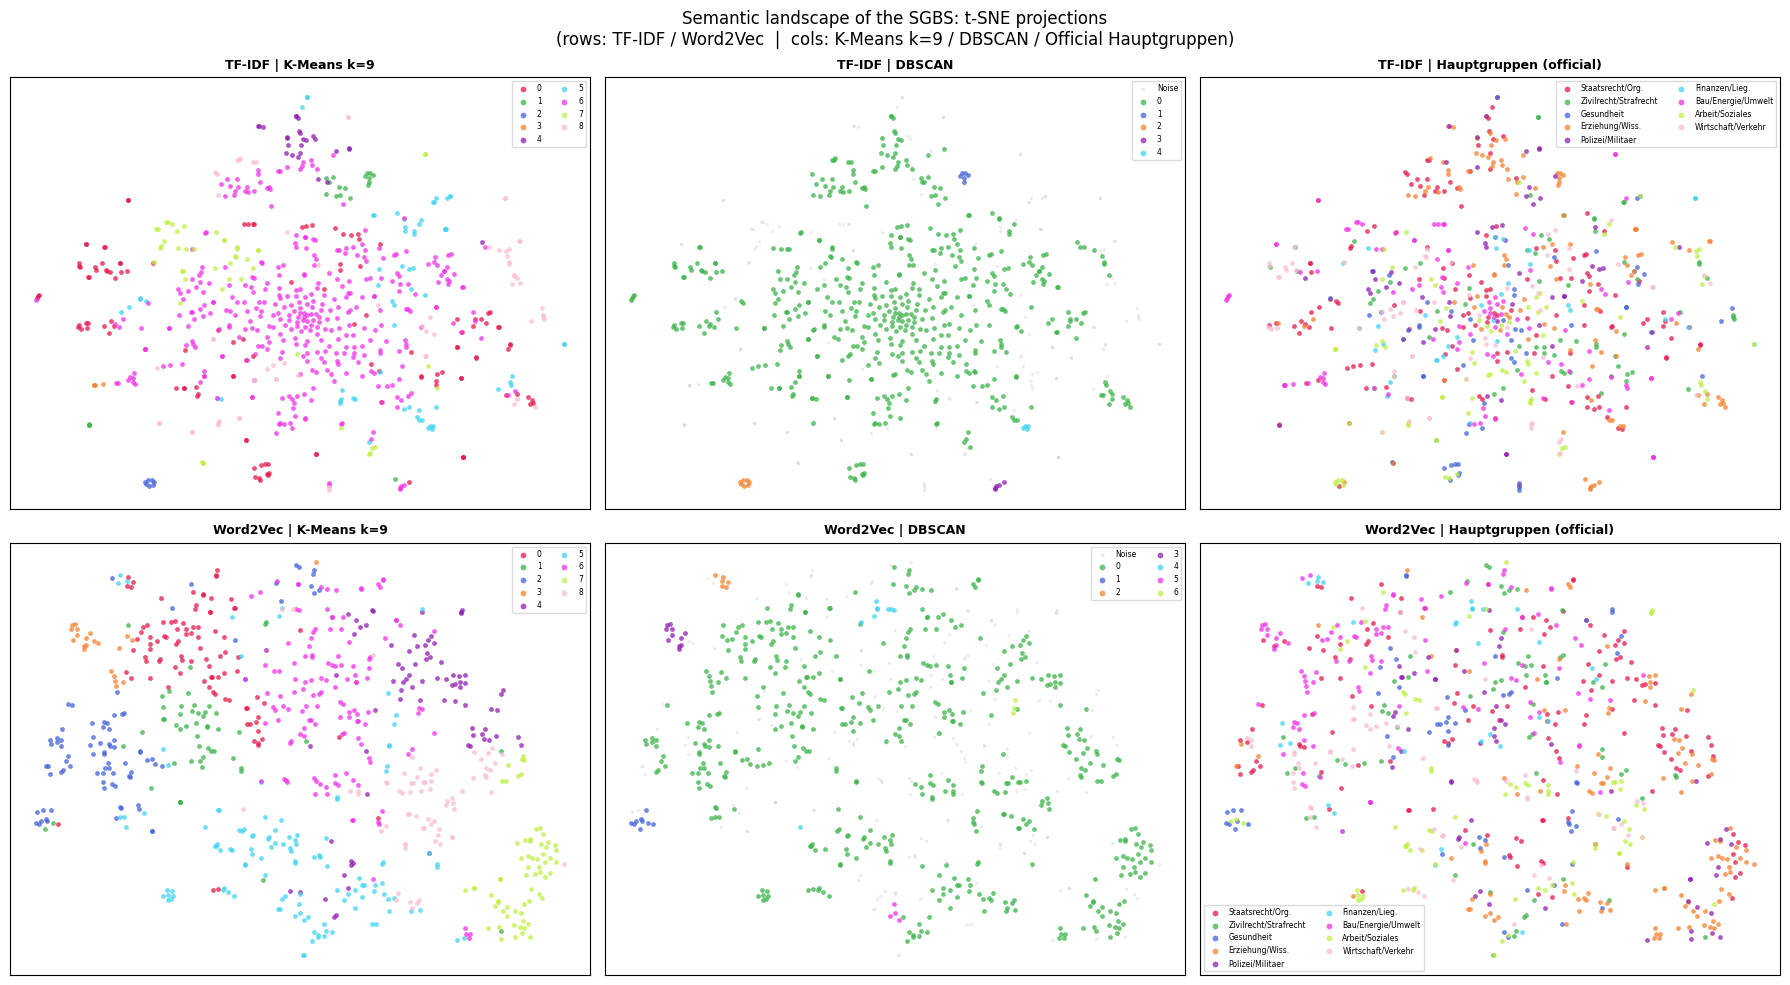

Figure saved: 05_3_tsne_overview.png


In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

configs = [
    # (row, col, X2d,          labels,              title,                               label_map)
    (0, 0, X_tfidf_tsne, km_tfidf_9.tolist(),   "TF-IDF | K-Means k=9",             None),
    (0, 1, X_tfidf_tsne, dbscan_tfidf.tolist(), "TF-IDF | DBSCAN",                  None),
    (0, 2, X_tfidf_tsne, hg_labels,             "TF-IDF | Hauptgruppen (official)",  HAUPTGRUPPEN),
    (1, 0, X_w2v_tsne,   km_w2v_9.tolist(),     "Word2Vec | K-Means k=9",            None),
    (1, 1, X_w2v_tsne,   dbscan_w2v.tolist(),   "Word2Vec | DBSCAN",                 None),
    (1, 2, X_w2v_tsne,   hg_labels,             "Word2Vec | Hauptgruppen (official)", HAUPTGRUPPEN),
]

for row, col, X2d, labels, title, label_map in configs:
    scatter_tsne(axes[row, col], X2d, labels, HG_COLORS, title, label_map=label_map)

plt.suptitle(
    "Semantic landscape of the SGBS: t-SNE projections\n"
    "(rows: TF-IDF / Word2Vec  |  cols: K-Means k=9 / DBSCAN / Official Hauptgruppen)",
    fontsize=12
)
plt.tight_layout()
plt.savefig("../report/figures/05_3_tsne_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 05_3_tsne_overview.png")

## 4. Anchor Documents per Hauptgruppe

For each of the 9 official Hauptgruppen, I select the document closest to the centroid of its group in TF-IDF t-SNE space. This anchor is the most representative law of that group geometrically. It is overlaid as a star on all four clustering views. The star colour matches the cluster it lands in; the label shows the official keyword.

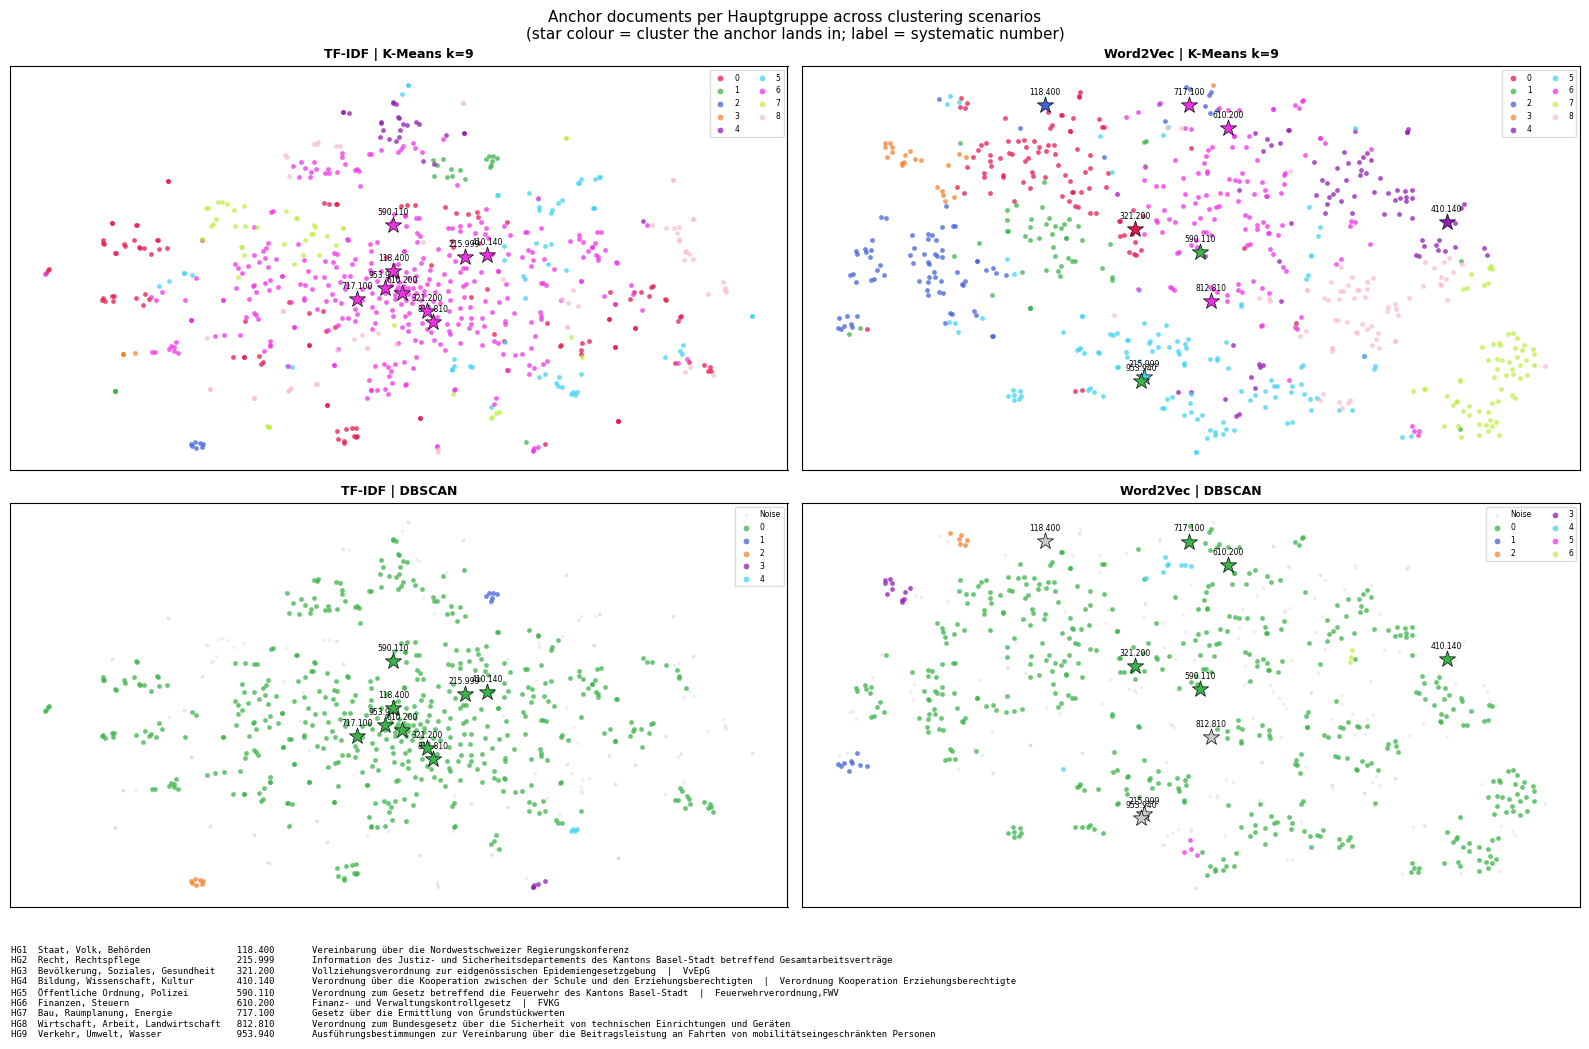

Figure saved: 05_3_tsne_anchors.png


In [45]:
# Official SGBS Hauptgruppen names
HG_NAMES = {
    '1': 'Staat, Volk, Behörden',
    '2': 'Recht, Rechtspflege',
    '3': 'Bevölkerung, Soziales, Gesundheit',
    '4': 'Bildung, Wissenschaft, Kultur',
    '5': 'Öffentliche Ordnung, Polizei',
    '6': 'Finanzen, Steuern',
    '7': 'Bau, Raumplanung, Energie',
    '8': 'Wirtschaft, Arbeit, Landwirtschaft',
    '9': 'Verkehr, Umwelt, Wasser',
}

# Select one anchor per Hauptgruppe: closest to HG centroid in TF-IDF t-SNE
ANCHORS = {}
for hg in '123456789':
    mask = np.array(hg_labels) == hg
    if mask.sum() == 0:
        continue
    pts = X_tfidf_tsne[mask]
    local_idx  = np.linalg.norm(pts - pts.mean(axis=0), axis=1).argmin()
    global_idx = np.where(mask)[0][local_idx]
    row        = df.iloc[global_idx]
    sysnum     = str(row['systematic_number'])
    title      = str(row['title_de'])
    kw         = row['keywords_de']
    keyword    = str(kw) if pd.notna(kw) else ''
    ANCHORS[hg] = (global_idx, sysnum, title, keyword)

def overlay_anchors(ax, X2d, cluster_labels, anchors):
    """Overlay anchor stars coloured by cluster; label = systematic_number."""
    cmap = label_colors(cluster_labels.tolist(), HG_COLORS)
    for hg, (idx, sysnum, title, keyword) in anchors.items():
        lbl   = cluster_labels[idx]
        color = cmap.get(lbl, '#cccccc')
        ax.scatter(X2d[idx, 0], X2d[idx, 1],
                   s=150, marker='*', color=color,
                   edgecolors='black', linewidths=0.5, zorder=5)
        ax.annotate(sysnum, xy=(X2d[idx, 0], X2d[idx, 1]),
                    xytext=(0, 6), textcoords='offset points',
                    fontsize=5.5, ha='center', va='bottom')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
configs = [
    (axes[0, 0], X_tfidf_tsne, km_tfidf_9,   "TF-IDF | K-Means k=9"),
    (axes[0, 1], X_w2v_tsne,   km_w2v_9,     "Word2Vec | K-Means k=9"),
    (axes[1, 0], X_tfidf_tsne, dbscan_tfidf, "TF-IDF | DBSCAN"),
    (axes[1, 1], X_w2v_tsne,   dbscan_w2v,   "Word2Vec | DBSCAN"),
]
for ax, X2d, labels, title in configs:
    scatter_tsne(ax, X2d, labels.tolist(), HG_COLORS, title)
    overlay_anchors(ax, X2d, labels, ANCHORS)

plt.suptitle(
    "Anchor documents per Hauptgruppe across clustering scenarios\n"
    "(star colour = cluster the anchor lands in; label = systematic number)",
    fontsize=11
)
plt.tight_layout(rect=[0, 0.22, 1, 1])

# Legend table below the plots
legend_lines = []
for hg, (idx, sysnum, title, keyword) in ANCHORS.items():
    hg_name = HG_NAMES.get(hg, '')
    kw_part = f'  |  {keyword}' if keyword else ''
    legend_lines.append(f"HG{hg}  {hg_name:<35}  {sysnum:<12}  {title}{kw_part}")
legend_text = '\n'.join(legend_lines)
fig.text(0.01, 0.20, legend_text, fontsize=6.5, va='top', family='monospace')

plt.savefig("../report/figures/05_3_tsne_anchors.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 05_3_tsne_anchors.png")